***Preparación de datos***

**Cargar datos tratados**

In [5]:
import pandas as pd

df = pd.read_csv("/datos_tratados.csv")

df.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


**Eliminar la columna que no sirve para el modelo**

In [6]:
df = df.drop(columns=["customerID"])

df.head()


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


**Verificar los tipos de datos**

In [7]:
df.dtypes


,0
Churn,int64
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


**Convertir variables categóricas (Encoding)**

In [8]:
df = pd.get_dummies(df, drop_first=True)

df.head()


,Churn,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Cuentas_Diarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,2.186667,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,1.996667,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,2.463333,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,3.266667,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,2.796667,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


**Ver proporción de cancelación (Churn)**

In [9]:
df["Churn"].value_counts()


,count
Churn,
0,5174
1,1869


In [10]:
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
0,0.73463
1,0.26537


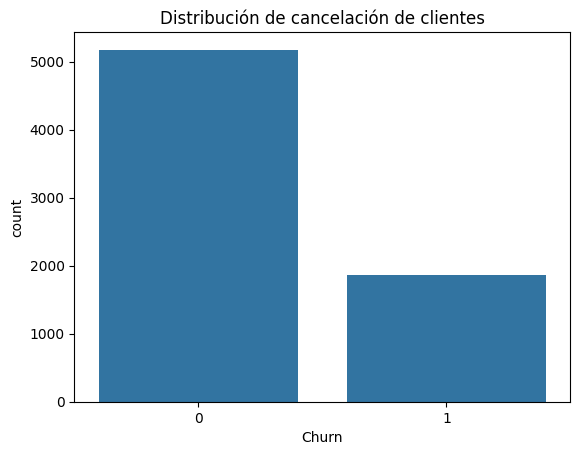

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Distribución de cancelación de clientes")
plt.show()


**Matriz de correlación.**

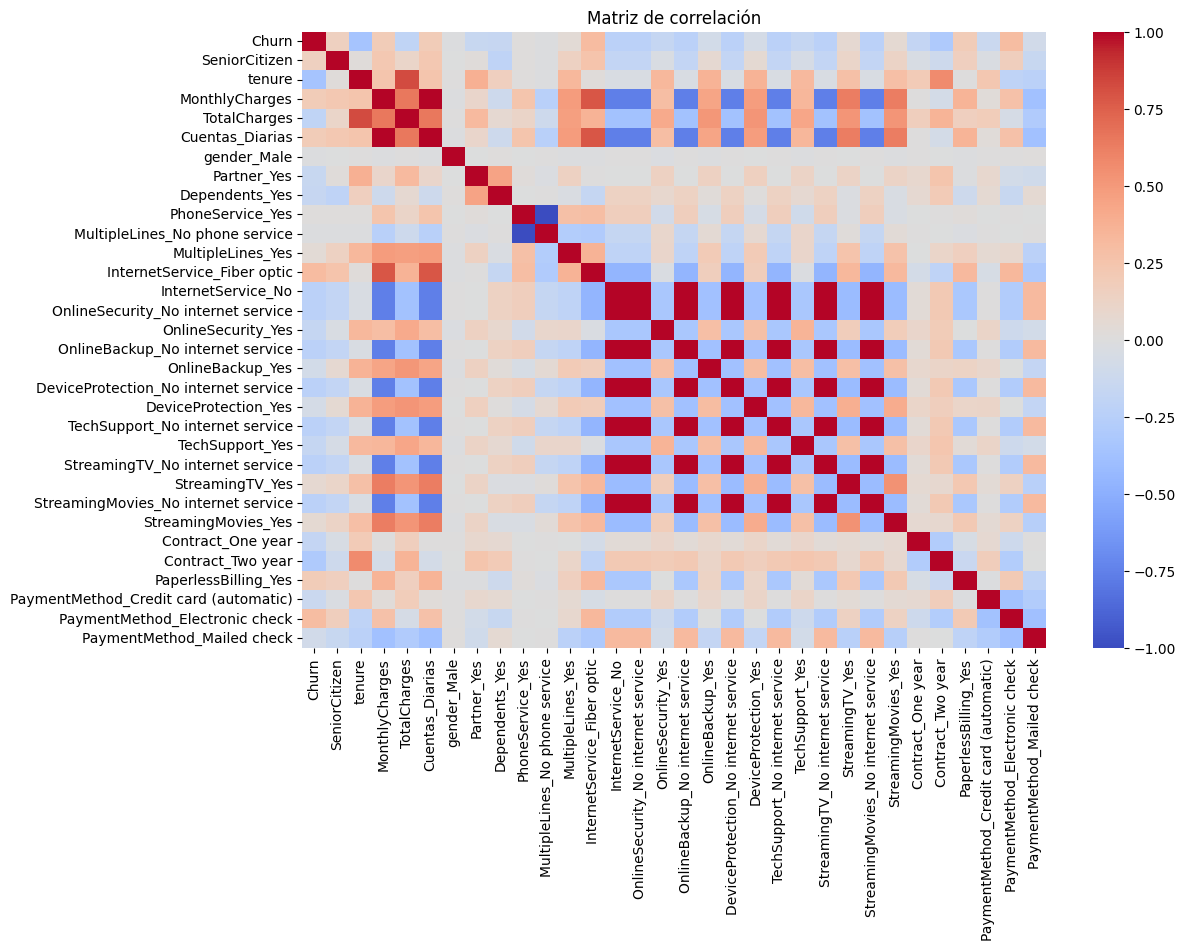

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


**Análisis dirigido**

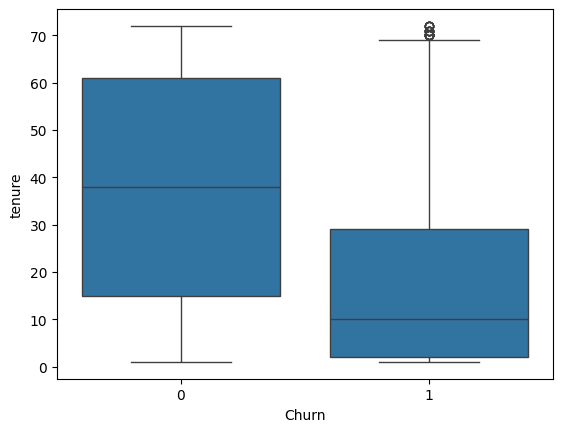

In [35]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()



**Separar variables X y Y**

In [16]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

**Separar datos de entrenamiento y prueba**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

obs: Verificar si Funciono

In [18]:
X_train.shape


(4930, 31)

Obs: Eliminar espacios vacios

In [20]:
df.isna().sum()


,0
Churn,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,11
Cuentas_Diarias,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0


In [21]:
df = df.dropna()


In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


**Crear el primer modelo (Regresión Logística)**

In [24]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000)

modelo_log.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [25]:
pred_log = modelo_log.predict(X_test)


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_log))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.65      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



**Hacer predicciones**

In [28]:
pred_log = modelo_log.predict(X_test)


**Evaluar el modelo**

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_log))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.65      0.57      0.60       556

    accuracy                           0.80      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.80      0.80      2110



**Crear el segundo modelo (Random Forest)**

In [30]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier()

modelo_rf.fit(X_train, y_train)


RandomForestClassifier()

**Predicciones del segundo modelo**

In [31]:
pred_rf = modelo_rf.predict(X_test)


**Evaluar Random Forest**

In [32]:
print(classification_report(y_test, pred_rf))


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1554
           1       0.62      0.50      0.56       556

    accuracy                           0.79      2110
   macro avg       0.73      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110



**Ver qué variables influyen más**

In [33]:
import pandas as pd

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
)

importancias.sort_values(ascending=False).head(10)


,0
TotalCharges,0.165014
tenure,0.155188
Cuentas_Diarias,0.128342
MonthlyCharges,0.125882
InternetService_Fiber optic,0.036810
PaymentMethod_Electronic check,0.034983
Contract_Two year,0.034975
gender_Male,0.024886
PaperlessBilling_Yes,0.023501
Contract_One year,0.023383


**Conclusión del proyecto**

En este proyecto se desarrollaron modelos de Machine Learning para predecir la cancelación de clientes (churn) en Telecom X utilizando los datos tratados en la Parte 1 del desafío.

Primero se realizó la preparación de los datos, incluyendo la eliminación de columnas irrelevantes, la codificación de variables categóricas mediante One-Hot Encoding y la verificación de la proporción de cancelación de clientes. Posteriormente se exploraron las relaciones entre variables mediante análisis de correlación y visualizaciones para identificar posibles factores asociados al churn.

Para el modelado predictivo se entrenaron dos modelos de clasificación:
- Regresión Logística
- Random Forest

Los modelos fueron evaluados utilizando métricas como accuracy, precision, recall y F1-score, además de la matriz de confusión para analizar el desempeño en la predicción de clientes que cancelan el servicio.

El modelo Random Forest presentó un mejor desempeño general, lo que lo convierte en una alternativa adecuada para este tipo de problema de clasificación.

El análisis de importancia de variables mostró que algunos de los factores más influyentes en la cancelación de clientes son:

- Tiempo de permanencia del cliente (tenure)
- Cargos mensuales (MonthlyCharges)
- Tipo de contrato
- Tipo de servicio de internet
- Método de pago

Los resultados sugieren que los clientes con menor tiempo de permanencia, contratos mensuales y mayores cargos mensuales presentan una mayor probabilidad de cancelar el servicio.

A partir de estos hallazgos, Telecom X podría implementar estrategias de retención dirigidas a estos perfiles de clientes, como:

- Ofrecer incentivos para migrar a contratos de mayor duración.
- Diseñar programas de fidelización para nuevos clientes.
- Analizar la relación entre precios y percepción de valor del servicio.

De esta manera, los modelos predictivos desarrollados pueden apoyar a la empresa en la identificación temprana de clientes con alto riesgo de cancelación, permitiendo tomar decisiones estratégicas para reducir el churn y mejorar la retención de clientes.
